In [1]:
import sys
import os

package_path="C:\\Users\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\pytorch-forecasting"



# Check if the directory exists
if os.path.exists(package_path):
    # Add the package path to sys.path
    sys.path.append(package_path)


print(sys.path)
import pandas as pd
import lightning.pytorch as pl
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer,TorchNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss,MultiHorizonMetric,RMSE
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters




<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_3156\2589346452.py:4: SyntaxWarning: invalid escape sequence '\O'
  package_path="C:\\Users\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\pytorch-forecasting"


['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.1776.0_x64__qbz5n2kfra8p0\\python312.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.1776.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.1776.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.1776.0_x64__qbz5n2kfra8p0', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\venv', '', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\venv\\Lib\\site-packages', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\venv\\Lib\\site-packages\\win32', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\venv\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\venv\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\OleJacobSimensen\\OneDrive - twoday

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_3156\2589346452.py:15: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Read & Transform Data

In [60]:
df=pd.read_csv("testML.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        unique_pos=new_filtered['position'].unique()
        for u in range(len(unique_pos)):
            times=[]
            pos=unique_pos[u]
            pos_filter=new_filtered[new_filtered['position'] == pos]
            filtered = pos_filter[pos_filter["minutes"] > 0]
            for g in range(len(filtered)):
                times.append(max_t-g)
            times.reverse()
            filtered["time"]=times
            if(len(unique_teamvals)>1):
                filtered['name']=filtered['name'].values[0]+str(t)
            time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
time_df.to_csv("ML_training2.csv")

print(time_df.columns)

87
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge Luiz_Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice' 'Bukayo_Saka'
 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney' 'Leandro_Trossard'
 'Benjamin_White' 'Oleksandr_Zinchenko' 'Norberto_Murara Neto'
 'Raheem_Sterling' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego Carlos_Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Robin_Olsen' 'Pau_Torres' 'Jacob_Ramsey' 'Morgan_Rogers'
 'Youri_Tielemans' 'Ollie_Watkins' 'Amadou_Onana' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed_Traorè' 'Milos_Kerkez' 'Justin_Kluivert'
 'Chris_Mepham' 'Dango_Ouattara' 'Philip_Billing' 'Alex_Scott'
 'A

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_7776\1282029567.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["time"]=times
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_7776\1282029567.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['name']=filtered['name'].values[0]+str(t)


Index(['assists', 'bonus', 'bps', 'clean_sheets', 'element',
       'expected_assists', 'expected_goal_involvements', 'expected_goals',
       'kickoff_time', 'expected_goals_conceded', 'fixture', 'goals_conceded',
       'goals_scored', 'minutes', 'opponent_team', 'saves', 'total_points',
       'value', 'was_home', 'Cluster', 'XGH', 'XGCH', 'XGA', 'XGCA',
       'Own_cluster', 'ICT', 'Threat', 'XGC_DEF', 'XGC_FWD', 'XGC_MID',
       'season', 'rolling_form', 'rolling_XG', 'rolling_XA', 'rolling_GC',
       'rolling_bps', 'rolling_GS', 'position', 'name', 'Team', 'available',
       'gamepos', 'xGChain', 'xGBuildup', 'time', 'rolling_Chain', 'Overscore',
       'Average_Overscore', 'rolling_ICT'],
      dtype='object')


In [24]:
import numpy as np
from sklearn.preprocessing import StandardScaler
positions=["FWD", "DEF","GK","MID"]
pos_ind=3


position_filter=positions[pos_ind]
positions_lookb=[5,5,5,5]
lstm_layer=[1,1,1,1]
AHs=[8,8,8,5]
AH=AHs[pos_ind]
lookb=positions_lookb[pos_ind]
lstm=lstm_layer[pos_ind]


df=pd.read_csv("ML_training2.csv").iloc[:,1:]
opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)


df["opposition_xg"]=opp_xg
df["opposition_xgc"]=opp_xgc
print(df[["was_home","XGH","opposition_xg"]])
df["Team"]=df["Team"].astype(str)
df["element"]=df["element"].astype(str)
df["Cluster"]=df["Cluster"].astype(str)
df["was_home"]=df["was_home"].astype(str)
df["gamepos"]=df["gamepos"].astype(str)
df["season"]=df["season"].astype(str)
df["Own_cluster"]=df["Own_cluster"].astype(str)
unknown=["assists", "bps","clean_sheets", "expected_assists","expected_goals","expected_goals_conceded","total_points","minutes","goals_scored","rolling_form" ]
knowncat=["Cluster","was_home","gamepos","season"]
knowncont=["opposition_xg","opposition_xgc",]
static=["name","Own_cluster"]
df['Overscore'] = df['Overscore'].fillna(0.8)
if(pos_ind==2):
    unknown=["bps","clean_sheets","expected_goals_conceded","total_points","minutes","rolling_form" ]
    knowncat=["Cluster","was_home"]
    knowncont=["opposition_xg"]
    static=["name","Own_cluster"]

if(pos_ind==1):
    unknown=["expected_goals_conceded","total_points","minutes","expected_assists","expected_goals","clean_sheets","ICT"]
    knowncat=["Cluster","was_home","gamepos"]
    knowncont=["opposition_xg"]
    static=["Own_cluster","name"]
    
if(pos_ind==0 or pos_ind==3 ):
    unknown=["expected_assists","expected_goals","total_points","minutes","goals_scored"]
    knowncat=["Cluster","was_home","gamepos"]
    knowncont=["opposition_xgc"]
    static=["name","Own_cluster"]
df['xGChain'] = df['xGChain'].fillna(0)

X_train=pd.DataFrame()
names= df['name'].unique()
print(names)
df=df[df['position'] == position_filter]
for i in range(len(names)):
    name=names[i]
    filtered= df[df['name'] == name]
    training_cutoff = filtered["time"].max() - 15

    name_df=filtered[lambda x: x.time <= training_cutoff]
    X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
    
scalers = {}
for feature in unknown:
    if feature != 'total_points':
        scaler = StandardScaler()
        print(X_train)
        X_train[feature] = scaler.fit_transform(X_train[[feature]])
        scalers[feature] = scaler
    
for feature in knowncont:
    scaler = StandardScaler()
    X_train[feature] = scaler.fit_transform(X_train[[feature]])
    scalers[feature] = scaler      
print(X_train)

X_test=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    filtered= df[df['name'] == name]
    training_cutoff = filtered["time"].max() - 10
    name_df=filtered[lambda x: x.time <= training_cutoff]
    X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

for feature, scaler in scalers.items():
    X_test[feature] = scaler.transform(X_test[[feature]])



df2=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    filtered= df[df['name'] == name]
    training_cutoff = filtered["time"].max() - 5
    name_df=filtered[lambda x: x.time <= training_cutoff]
    df2=pd.concat([df2, name_df], axis=0, ignore_index=True)
for feature, scaler in scalers.items():
    df2[feature] = scaler.transform(df2[[feature]])
    
preds_list=["Luis_Díaz"]
filtered_df = df2[df2['name'].isin(preds_list)]
filtered_df.to_csv("teset2.csv")
print(filtered_df)

correlation_matrix = X_train[["bps","expected_assists","expected_goals","total_points","minutes","ICT", "Threat"]].corr()
print(correlation_matrix)
"""preds_list=["Gabriel_dos Santos Magalhães"]
filtered_df = df2[df2['name'].isin(preds_list)]
filtered_df.to_csv("teset2.csv")
print(filtered_df)"""

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_32984\3003924816.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_32984\3003924816.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)


       was_home   XGH  opposition_xg
0         False  2.00           2.00
1         False  1.80           1.80
2          True  1.80           1.60
3          True  2.25           1.60
4         False  1.40           1.40
...         ...   ...            ...
27143      True  2.20           1.45
27144     False  1.50           1.50
27145     False  1.80           1.80
27146      True  1.30           1.20
27147     False  1.20           1.20

[27148 rows x 3 columns]
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge Luiz_Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice' 'Bukayo_Saka'
 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney' 'Leandro_Trossard'
 'Benjamin_White' 'Oleksandr_Zinchenko' 'Norberto_Murara Neto'
 'Raheem_Sterling' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego Carlos_Santos 

'preds_list=["Gabriel_dos Santos Magalhães"]\nfiltered_df = df2[df2[\'name\'].isin(preds_list)]\nfiltered_df.to_csv("teset2.csv")\nprint(filtered_df)'

# Make TimeSeriesDataSet object

In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
X = X_train[["expected_assists","expected_goals","total_points","minutes","ICT","goals_scored","Overscore"]]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

            feature       VIF
0  expected_assists  1.338387
1    expected_goals  2.437989
2      total_points  2.995661
3           minutes  1.496989
4               ICT  4.716472
5      goals_scored  3.249447
6         Overscore  1.789484


In [102]:
string=position_filter+"TFT.csv"
print(string)

ForwardTFT.csv


In [25]:
max_prediction_length = 5
max_encoder_length = lookb
from pytorch_forecasting.data.encoders import NaNLabelEncoder
training = TimeSeriesDataSet(
    X_train,
    time_idx="time",
    target="total_points",
    group_ids=["name"],  # keep encoder length long (as it is in the validation set)
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length,
    static_categoricals=static,
    allow_missing_timesteps=True,

    
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    time_varying_known_categoricals=knowncat,
    time_varying_known_reals=knowncont,
    time_varying_unknown_reals=unknown,
    target_normalizer=TorchNormalizer(),
    categorical_encoders={
        "gamepos": NaNLabelEncoder(add_nan=True),  # Handle unknown categories
        "name" : NaNLabelEncoder(add_nan=True)
    },
    add_relative_time_idx=True,
    #add_target_scales=True,
    #add_encoder_length=True,


)

validation = TimeSeriesDataSet.from_dataset(training, X_test, predict=True, stop_randomization=True)

batch_size = 64 # set this between 32 to 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=10,persistent_workers=True)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*6, num_workers=10,persistent_workers=True)
data_df = training.data

# Display the first few rows of the data
print(data_df)

{'reals': tensor([[ 0.0308,  0.0000, -0.5111,  ...,  0.0000,  0.8209, -0.3547],
        [-0.8131,  0.0000, -0.6496,  ...,  0.0000, -1.0124, -0.3547],
        [ 0.0308,  0.0000, -0.5803,  ...,  0.0000, -1.8308, -0.3547],
        ...,
        [ 0.5934,  0.0000, -0.1649,  ...,  0.0000,  0.7882, -0.3547],
        [-0.2505,  0.0000, -0.4419,  ...,  0.0000,  0.8209, -0.3547],
        [-0.2505,  0.0000, -0.5111,  ...,  0.0000,  0.0025, -0.3547]]), 'categoricals': tensor([[  1,   3,   1,   1,  13],
        [  1,   3,   1,   0,  13],
        [  1,   3,   1,   1,  17],
        ...,
        [228,   0,   1,   1,   6],
        [228,   0,   0,   0,   6],
        [228,   0,   1,   0,   6]]), 'groups': tensor([[  0],
        [  0],
        [  0],
        ...,
        [227],
        [227],
        [227]]), 'target': [tensor([2., 1., 1.,  ..., 2., 3., 1.])], 'weight': None, 'time': tensor([21, 22, 23,  ..., 68, 69, 70])}


C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\data\timeseries.py:1281: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 16 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__name': 'Amad_Diallo'}, {'__group_id__name': 'André_Ayew'}, {'__group_id__name': 'André_Tavares Gomes'}, {'__group_id__name': 'Arnaut_Danjuma Groeneveld'}, {'__group_id__name': 'Bryan_Gil Salvatierra'}, {'__group_id__name': 'Christopher_Nkunku'}, {'__group_id__name': 'Georginio_Rutter'}, {'__group_id__name': 'Gonçalo Manuel_Ganchinho Guedes'}, {'__group_id__name': 'Jack_Colback'}, {'__group_id__name': 'Lesley_Ugochukwu'}]
  warnings.warn(
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\data\encoders.py:318: UserWarning: Fo

In [243]:
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
q=[0.2, 0.5, 0.8]
# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=20,
    max_epochs=30,
    gradient_clip_val_range=(0.01, 5.0),
    hidden_size_range=(8, 64),
    hidden_continuous_size_range=(4, 64),
    attention_head_size_range=(1,4),
    dropout_range=(0.1, 0.3),
    reduce_on_plateau_patience=10,
    use_learning_rate_finder=True,
    loss=RMSE()# use Optuna to find ideal learning rate or use in-built learning rate finder
)
print(study.best_trial.params)
#Trial 1 finished with value: 1.071542501449585 and parameters: {'gradient_clip_val': 0.024912337685929323, 'hidden_size': 9, 'dropout': 0.11891728326828235, 'hidden_continuous_size': 9, 'attention_head_size': 2, 'learning_rate': 0.002778271197058573}
#1.238646149635315 and parameters: {'gradient_clip_val': 4.268707211031744, 'hidden_size': 55, 'dropout': 0.21641417200184665, 'hidden_continuous_size': 5, 'attention_head_size': 3, 'learning_rate': 0.011220184543019632}. Best is trial 1 with value: 1.238646149635315.
#{'gradient_clip_val': 0.06613574889565431, 'hidden_size': 21, 'dropout': 0.15102169335508475, 'hidden_continuous_size': 5, 'attention_head_size': 4, 'learning_rate': 0.03548133892335753}






#MID

#2.919548511505127 and parameters: {'gradient_clip_val': 0.017751652571309017, 'hidden_size': 18, 'dropout': 0.25590094306960043, 'hidden_continuous_size': 5, 'attention_head_size': 2, 'learning_rate': 0.17782794100389224}


#Attk
#2.7618048191070557 and parameters: {'gradient_clip_val': 0.031627450966409926, 'hidden_size': 48, 'dropout': 0.1073524905929054, 'hidden_continuous_size': 16, 'attention_head_size': 3, 'learning_rate': 0.006309573444801936}.
 
#DEF
#3.5006179809570312 and parameters: {'gradient_clip_val': 0.2959267772988762, 'hidden_size': 29, 'dropout': 0.10167396582794855, 'hidden_continuous_size': 7, 'attention_head_size': 1, 'learning_rate': 0.03162277660168378}. Best is trial 0 with value: 3.5006179809570312.

[I 2024-08-31 20:41:42,718] A new study created in memory with name: no-name-e34ebe4c-1383-4148-9f35-44037c0e5c06
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\models\temporal_fusion_transformer\tuning.py:124: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gradient_clip_val = trial.suggest_loguniform("gradient_clip_val", *gradient_clip_val_range)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\models\temporal_fusion_transformer\tuning.py:148: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/opt

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.06309573444801933
Restoring states from the checkpoint path at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_dc2be563-4bb5-45fd-b761-27b9557347c7.ckpt
Restored all states from the checkpoint at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_dc2be563-4bb5-45fd-b761-27b9557347c7.ckpt
[I 2024-08-31 20:42:02,853] Using learning rate of 0.0708
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\models\temporal_fusion_transformer\tuning.py:194: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  model.hparams.learning_rate = trial.suggest_uniform("learning_rate", optimal_lr, optimal_lr)
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\ligh

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.03548133892335753
Restoring states from the checkpoint path at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_e612fad0-cf7d-48a4-b2fd-ce6b34eda336.ckpt
Restored all states from the checkpoint at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_e612fad0-cf7d-48a4-b2fd-ce6b34eda336.ckpt
[I 2024-08-31 20:43:33,754] Using learning rate of 0.0631
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:652: Checkpoint directory C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\optuna_test\trial_1 exists and is not empty.
`Trainer.fit` stopped: `max_epochs=30` reached.
[I 2024-08-31 20:44:42,101] Trial 1 finished with value: 3.701744556427002 and parameters: {'gradient_clip_val': 0.08560205137270441, 'hidden_size': 19, 'dropout': 0.2817642350446513, 'hidden_continuous_size':

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.056234132519034905
Restoring states from the checkpoint path at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_b0a214db-1e86-493f-8179-f974c1d5dc40.ckpt
Restored all states from the checkpoint at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_b0a214db-1e86-493f-8179-f974c1d5dc40.ckpt
[I 2024-08-31 20:45:03,686] Using learning rate of 0.0447
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:652: Checkpoint directory C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\optuna_test\trial_2 exists and is not empty.
[I 2024-08-31 20:45:17,584] Trial 2 pruned. Trial was pruned at epoch 1.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TP

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.06309573444801933
Restoring states from the checkpoint path at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_df2d5f0c-7ba7-403c-b8c8-57ffea67a469.ckpt
Restored all states from the checkpoint at C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\.lr_find_df2d5f0c-7ba7-403c-b8c8-57ffea67a469.ckpt
[I 2024-08-31 20:45:32,834] Using learning rate of 0.0501
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:652: Checkpoint directory C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\optuna_test\trial_3 exists and is not empty.
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\trainer\call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...
[W 2024-08-31 20:45:37,462] Trial 3 failed with parameters: {'gradient

# Fit Model

In [23]:
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(torch.cuda.is_available())

False


In [26]:

#Midfield=0.003,16,16,8, 64, 5, 0.1 epoch 5/10
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-6, patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard
from lightning.pytorch import Trainer, seed_everything

seed_everything(33, workers=True)
q=[0.2, 0.5, 0.8]
trainer = pl.Trainer(
    max_epochs=5,
    enable_model_summary=True,
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,
    hidden_size=64,
    attention_head_size=1,
    dropout=0.2,
    hidden_continuous_size=4,
    loss=RMSE(),
    #log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="Ranger",
    lstm_layers=lstm,
    reduce_on_plateau_patience=10,
    
    
    
)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")


trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    
)



Seed set to 33
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:199: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Number of parameters in network: 233.9k



   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 8.0 K 
3  | prescalers                         | ModuleDict                      | 56    
4  | static_variable_selection          | VariableSelectionNetwork        | 488   
5  | encoder_variable_selection         | VariableSelectionNetwork        | 9.1 K 
6  | decoder_variable_selection         | VariableSelectionNetwork        | 3.1 K 
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 16.8 K
9  | static_context_initial_cell_lstm   | GatedResidualNetwork            | 16.8

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=5` reached.


# Accuracy of full model

In [143]:
"""best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)"""
raw_predictions =tft.predict(val_dataloader, mode="raw", return_x=True)
print(raw_predictions)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:492: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Prediction(output=Output(prediction=tensor([[[-3.7842e-02,  9.3893e-02,  2.7769e-01,  ...,  2.3634e+00,
           5.7710e+00,  1.0274e+01],
         [-3.8668e-02,  7.3702e-02,  1.5706e-01,  ...,  2.0890e+00,
           5.2478e+00,  9.6674e+00],
         [-2.4971e-02,  9.3439e-02,  2.5449e-01,  ...,  2.6924e+00,
           6.1442e+00,  1.0746e+01],
         [-3.5271e-02,  7.2088e-02,  1.3847e-01,  ...,  2.1187e+00,
           5.2283e+00,  9.6576e+00],
         [-2.8794e-02,  7.6743e-02,  1.3122e-01,  ...,  2.1760e+00,
           5.2544e+00,  9.7026e+00]],

        [[-7.6566e-02,  2.3476e-03,  1.6272e-02,  ...,  7.3912e-01,
           1.8331e+00,  6.3802e+00],
         [-6.6749e-02,  3.3213e-02,  5.7233e-02,  ...,  1.1798e+00,
           2.9142e+00,  8.0486e+00],
         [-5.7549e-02,  4.1537e-02,  5.0073e-02,  ...,  1.3979e+00,
           3.4840e+00,  8.5029e+00],
         [-5.7493e-02,  4.3468e-02,  5.4341e-02,  ...,  1.4728e+00,
           3.6136e+00,  8.5834e+00],
         [-5.7811

In [27]:

def predset(filtered_df,ki):
    max_prediction_length = 5
    max_encoder_length = lookb
    training = TimeSeriesDataSet(
        filtered_df,
        time_idx="time",
        target="total_points",
        group_ids=["name"],  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_encoder_length=5,
        static_categoricals=static,
        allow_missing_timesteps=True,

        time_varying_known_reals=knowncont,
        min_prediction_length=max_prediction_length,
        max_prediction_length=max_prediction_length,
        time_varying_known_categoricals=knowncat,
        time_varying_unknown_reals=unknown,
        target_normalizer=TorchNormalizer(),
        #add_relative_time_idx=True,
        predict_mode=True,
        #add_target_scales=True,
        add_relative_time_idx=True,


    )

    validation = TimeSeriesDataSet.from_dataset(training, filtered_df, predict=True, stop_randomization=True)

    batch_size = 1 # set this between 32 to 128
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=19,persistent_workers=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=19,persistent_workers=True)
    data_df = training.data
    return val_dataloader



In [28]:
#print(raw_predictions)
import torch
import torch.nn as nn
criterion = nn.MSELoss()
player_list=["Son_Heung-min","Kevin_De Bruyne","Phil_Foden","Erling_Haaland","Alejandro_Garnacho","Anthony_Gordon","James_Maddison",
            "Pedro_Porro","Jarrod_Bowen","Hwang_Hee-chan","Matheus_Santos Carneiro Da Cunha","Pedro_Lomba Neto","Gabriel_dos Santos Magalhães","Kai_Havertz","Gabriel_Martinelli Silva",
            "Martin_Ødegaard","Bukayo_Saka","Benjamin_White","Leon_Bailey","Ollie_Watkins","Dominic_Solanke","Illia_Zabarnyi","Ivan_Toney","Pervis_Estupiñán",
            "Pascal_Groß","Cole_Palmer","Joachim_Andersen","Eberechi_Eze","Michael_Olise","Vitalii_Mykolenko","Luis_Díaz","Mohamed_Salah","Virgil_van Dijk","Darwin_Núñez Ribeiro",
            "Julián_Álvarez","Charlie_Taylor","Jean-Philippe_Mateta","Dominic_Calvert-Lewin","Trent_Alexander-Arnold","Alfie_Doughty",
             "Bruno_Borges Fernandes","William_Saliba","Lucas_Digne","Moussa_Diaby","Mark_Flekken","Kaoru_Mitoma","Malo_Gusto","Nicolas_Jackson",
            "Bernd_Leno","Jack_Grealish","Marcus_Rashford","Alexander_Isak","Dan_Burn","Kieran_Trippier","Morgan_Gibbs-White","Richarlison_de Andrade"
            ,"Rayan_Aït-Nouri","Pablo_Sarabia","Rodrigo_Hernandez","Joško_Gvardiol","Diogo_Dalot Teixeira","Rasmus_Højlund","Martin_Dubravka","Fabian_Schär","Anthony_Elanga",
           "David_Raya Martin","Emiliano_Martínez Romero","Bryan_Mbeumo","Sergio_Reguilón","Lewis_Dunk","Ben_Chilwell","Conor_Gallagher","Dean_Henderson","Jordan_Pickford",
           "Alexis_Mac Allister","Dejan_Kulusevski","Vladimír_Coufal","Ben_Davies","Harry_Maguire","Timothy_Castagne","Tyrick_Mitchell","Rico_Henry"]
player_list= df2['name'].unique()

player_preds=[]
MSE_preds=[]
MSE_real=[]
for i in range (len(player_list)):
    preds_list=[]
    player=player_list[i]
    print(player)
    preds_list.append(player)
    filtered_df = df[df['name'].isin(preds_list)]
    filtered_df=df2[df2["name"].isin(preds_list)]
    
    if(len(filtered_df)<20):
        continue
    print(filtered_df["total_points"].tail())
    val_dataloader=predset(filtered_df,lookb)
    raw_predictions =tft.predict(val_dataloader, mode="raw", return_x=True)

    
    idx=0
    if(len(raw_predictions[1]['decoder_time_idx'])>1 and raw_predictions[1]['decoder_time_idx'][0][0]<raw_predictions[1]['decoder_time_idx'][1][0] ):
        idx=1
    print(idx)
    for t in range (len(raw_predictions[1]['decoder_target'][idx])):
        MSE_real.append(raw_predictions[1]['decoder_target'][idx][t])
        print(raw_predictions[1]['decoder_target'][idx])
    preds=raw_predictions[0][0][idx]
    for j in range(len(preds)):
        preds_list.append(preds[j][0].item())
        MSE_preds.append(preds[j][0].item())
    for k in range(len(preds)):
        preds_list.append(preds[k][-1].item())
    player_preds.append(preds_list)
    print(preds_list)


print(criterion(torch.tensor(MSE_preds), torch.tensor(MSE_real)))
columns=["Name","p1","p2","p3","p4","p5","top1","top2","top3","top4","top5"]
data_f=pd.DataFrame(player_preds, columns=columns)
print(data_f)
datastring=position_filter+"TFT.csv"
data_f.to_csv(datastring)
        
#tensor(12.7575
#6.53
#tensor(12.0208)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Fábio_Ferreira Vieira
28    1
29   -2
30    1
31    1
32    1
Name: total_points, dtype: int64


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


0
tensor([ 1., -2.,  1.,  1.,  1.])
tensor([ 1., -2.,  1.,  1.,  1.])
tensor([ 1., -2.,  1.,  1.,  1.])
tensor([ 1., -2.,  1.,  1.,  1.])
tensor([ 1., -2.,  1.,  1.,  1.])
['Fábio_Ferreira Vieira', 1.1461374759674072, 1.6800479888916016, 2.301257848739624, 1.5037411451339722, 2.372877836227417, 1.1461374759674072, 1.6800479888916016, 2.301257848739624, 1.5037411451339722, 2.372877836227417]
Kai_Havertz
104     6
105    12
106     2
107     8
108     2
Name: total_points, dtype: int64


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


...

0
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
['Wataru_Endo', 1.6711941957473755, 1.6881624460220337, 1.8370949029922485, 1.2717435359954834, 1.924730658531189, 1.6711941957473755, 1.6881624460220337, 1.8370949029922485, 1.2717435359954834, 1.924730658531189]
Nicolò_Zaniolo
11766    1
11767    2
11768    1
11769    3
11770    1
Name: total_points, dtype: int64


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


0
tensor([1., 2., 1., 3., 1.])
tensor([1., 2., 1., 3., 1.])
tensor([1., 2., 1., 3., 1.])
tensor([1., 2., 1., 3., 1.])
tensor([1., 2., 1., 3., 1.])
['Nicolò_Zaniolo', 1.5614103078842163, 0.7336426973342896, 1.2433252334594727, 0.736742377281189, 0.8246264457702637, 1.5614103078842163, 0.7336426973342896, 1.2433252334594727, 0.736742377281189, 0.8246264457702637]
Anssumane_Fati Vieira
Sofyan_Amrabat
11806    1
11807    0
11808    2
11809    1
11810    2
Name: total_points, dtype: int64


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


0
tensor([1., 0., 2., 1., 2.])
tensor([1., 0., 2., 1., 2.])
tensor([1., 0., 2., 1., 2.])
tensor([1., 0., 2., 1., 2.])
tensor([1., 0., 2., 1., 2.])
['Sofyan_Amrabat', 1.7205023765563965, 1.2823864221572876, 1.1565719842910767, 1.300034999847412, 1.3449509143829346, 1.7205023765563965, 1.2823864221572876, 1.1565719842910767, 1.300034999847412, 1.3449509143829346]
Yegor_Yarmoliuk
11833    1
11834    1
11835    1
11836    1
11837    1
Name: total_points, dtype: int64
0
tensor([1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1.])
['Yegor_Yarmoliuk', 1.2959192991256714, 1.0787767171859741, 1.5911091566085815, 1.2000991106033325, 1.6270782947540283, 1.2959192991256714, 1.0787767171859741, 1.5911091566085815, 1.2000991106033325, 1.6270782947540283]
tensor(7.6992)
                         Name        p1        p2        p3        p4  \
0       Fábio_Ferreira Vieira  1.146137  1.680048  2.301258  1.503741   
1   

In [129]:
torch.save(tft.state_dict(), 'TFT_FWD.pth')

In [65]:
tft.load_state_dict(torch.load('TFT_MID.pth'))
tft.eval()
raw_predictions =tft.predict(val_dataloader, mode="raw", return_x=True)
idx=0
if(len(raw_predictions[1]['decoder_time_idx'])>1 and raw_predictions[1]['decoder_time_idx'][0][0]<raw_predictions[1]['decoder_time_idx'][1][0] ):
    idx=1
print(idx)
for t in range (len(raw_predictions[1]['decoder_target'][idx])):
    MSE_real.append(raw_predictions[1]['decoder_target'][idx][t])
    print(raw_predictions[1]['decoder_target'][idx])
preds=raw_predictions[0][0][idx]
for j in range(len(preds)):
    preds_list.append(preds[j][0].item())
    MSE_preds.append(preds[j][0].item())
for k in range(len(preds)):
    preds_list.append(preds[k][-1].item())
player_preds.append(preds_list)
print(preds_list)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


0
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
tensor([1., 1., 3., 2., 2.])
['Wataru_Endo', 1.428263783454895, 1.2946150302886963, 1.4687104225158691, 1.2268410921096802, 1.4843226671218872, 1.428263783454895, 1.2946150302886963, 1.4687104225158691, 1.2268410921096802, 1.4843226671218872, 1.428263783454895, 1.2946150302886963, 1.4687104225158691, 1.2268410921096802, 1.4843226671218872, 1.428263783454895, 1.2946150302886963, 1.4687104225158691, 1.2268410921096802, 1.4843226671218872]


In [56]:
columns=["Name","p1","top1"]
data_f=pd.DataFrame(player_preds, columns=columns)
print(data_f)
datastring=position_filter+"TFT.csv"
data_f.to_csv(datastring)
        

                           Name        p1      top1
0                   Kai_Havertz  5.403618  5.403618
1       Jorge Luiz_Frello Filho  2.854540  2.854540
2      Gabriel_Martinelli Silva  4.558514  4.558514
3               Martin_Ødegaard  6.158353  6.158353
4                 Thomas_Partey  2.463997  2.463997
..                          ...       ...       ...
158  João Victor_Gomes da Silva  2.121667  2.121667
159                Mario_Lemina  2.310050  2.310050
160            Pedro_Lomba Neto  2.972210  2.972210
161               Pablo_Sarabia  1.862140  1.862140
162             Boubacar_Traoré  1.043557  1.043557

[163 rows x 3 columns]


In [18]:
interpretation = tft.interpret_output(raw_predictions.output, reduction="mean")
print(interpretation)
print(tft.get_attention_mask(train_dataloader,val_dataloader))

{'attention': tensor([0.1258, 0.1579, 0.3420, 0.2069, 0.1674]), 'static_variables': tensor([0.3569, 0.6431]), 'encoder_variables': tensor([0.0558, 0.0669, 0.2628, 0.0301, 0.0209, 0.0867, 0.0375, 0.0179, 0.2406,
        0.0339, 0.1470]), 'decoder_variables': tensor([0.2768, 0.1221, 0.3863, 0.0346, 0.1802]), 'encoder_length_histogram': tensor([0, 0, 0, 0, 0, 1]), 'decoder_length_histogram': tensor([0, 0, 0, 0, 1])}


AttributeError: 'DataLoader' object has no attribute 'max'

# Test for other predictions

{'attention': tensor([0.6110, 0.0566, 0.0593, 0.1205, 0.1526]), 'static_variables': tensor([0.8436, 0.1564]), 'encoder_variables': tensor([0.0644, 0.1178, 0.1892, 0.0561, 0.0871, 0.0133, 0.1964, 0.0286, 0.0481,
        0.1990]), 'decoder_variables': tensor([0.3159, 0.0867, 0.4422, 0.0956, 0.0597]), 'encoder_length_histogram': tensor([0, 0, 0, 0, 0, 1]), 'decoder_length_histogram': tensor([0, 0, 0, 0, 1])}


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x250 with 1 Axes>,
 'encoder_variables': <Figure size 700x450 with 1 Axes>,
 'decoder_variables': <Figure size 700x325 with 1 Axes>}

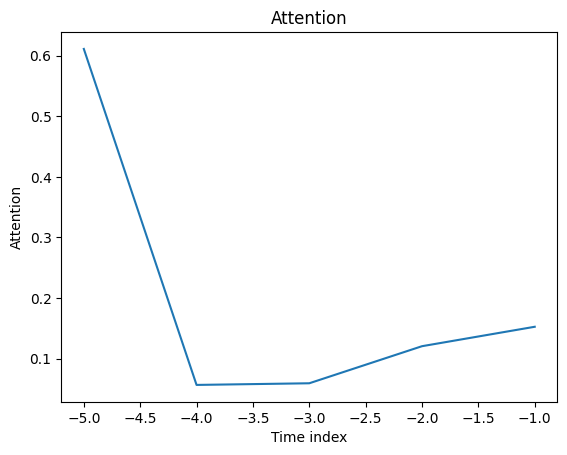

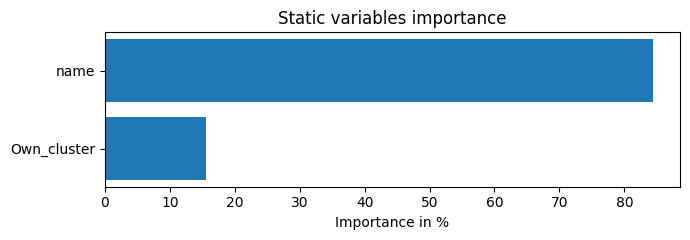

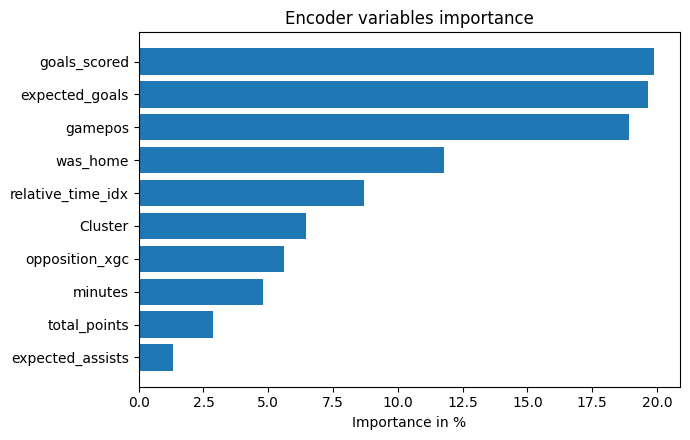

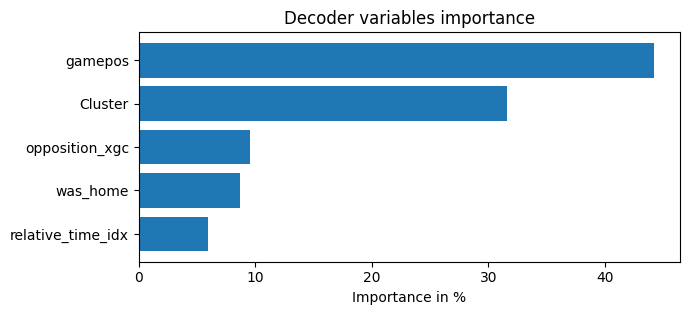

In [21]:
interpretation = tft.interpret_output(raw_predictions.output, reduction="mean")
print(interpretation)
tft.plot_interpretation(interpretation)

C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\data\timeseries.py:1281: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 16 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__name': 'Amad_Diallo'}, {'__group_id__name': 'André_Ayew'}, {'__group_id__name': 'André_Tavares Gomes'}, {'__group_id__name': 'Arnaut_Danjuma Groeneveld'}, {'__group_id__name': 'Bryan_Gil Salvatierra'}, {'__group_id__name': 'Christopher_Nkunku'}, {'__group_id__name': 'Georginio_Rutter'}, {'__group_id__name': 'Gonçalo Manuel_Ganchinho Guedes'}, {'__group_id__name': 'Jack_Colback'}, {'__group_id__name': 'Lesley_Ugochukwu'}]
  warnings.warn(
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\pytorch-forecasting\pytorch_forecasting\data\encoders.py:318: UserWarning: Fo

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU co

['32416453351', '64416453351', '64813253351']
[tensor(6.7492), tensor(6.5882), tensor(6.7201)]
fasit
64416453351


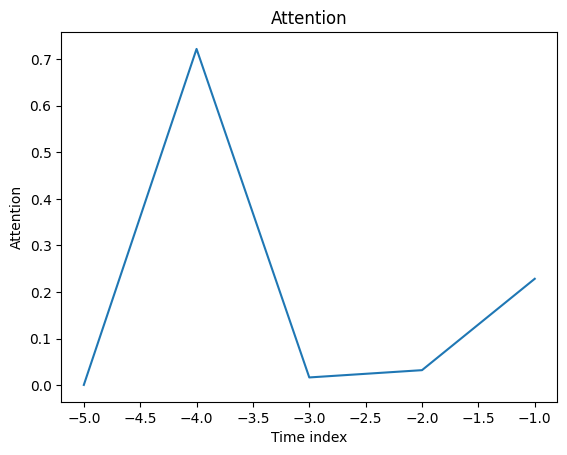

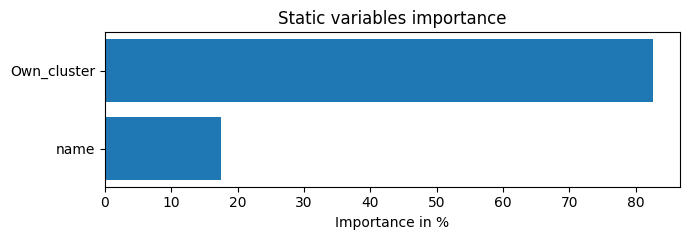

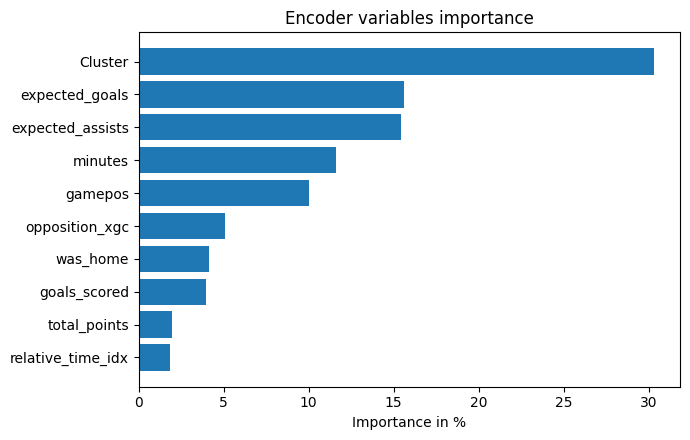

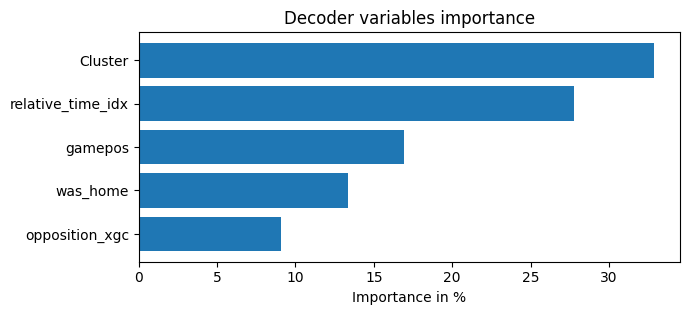

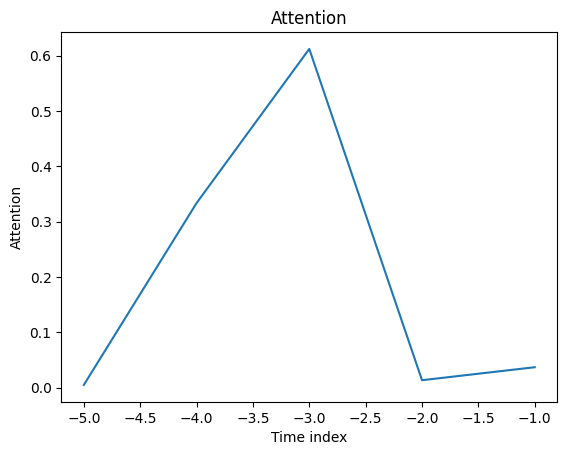

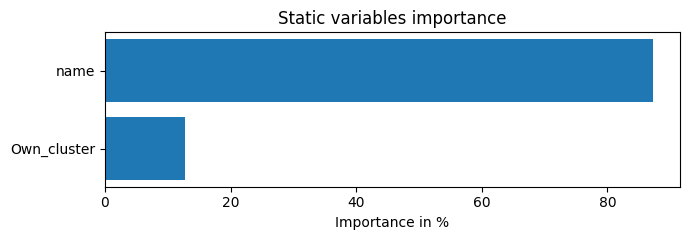

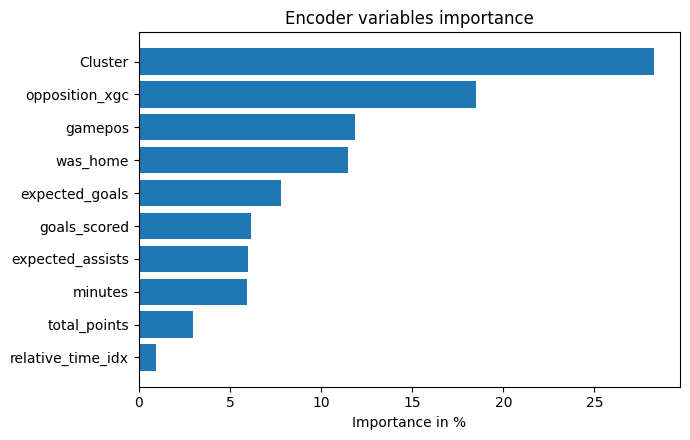

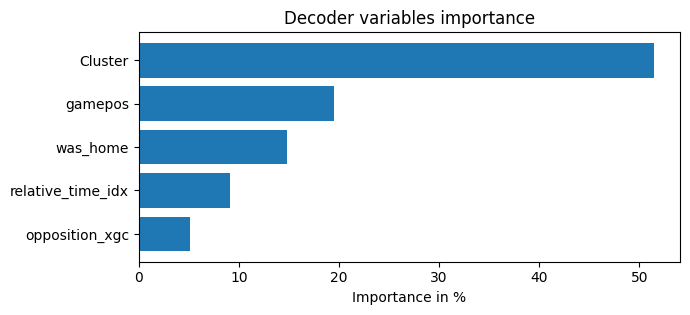

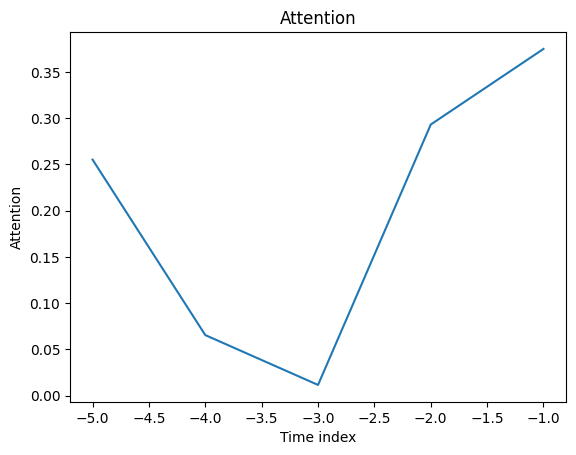

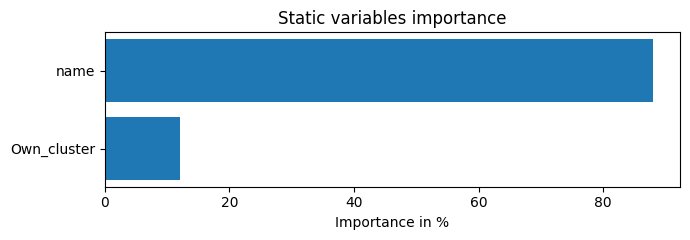

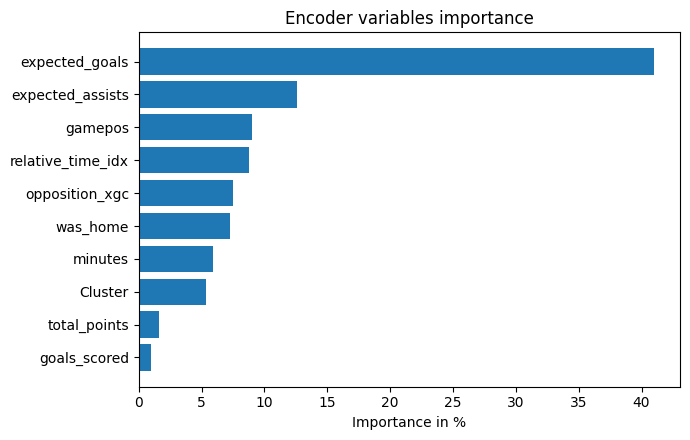

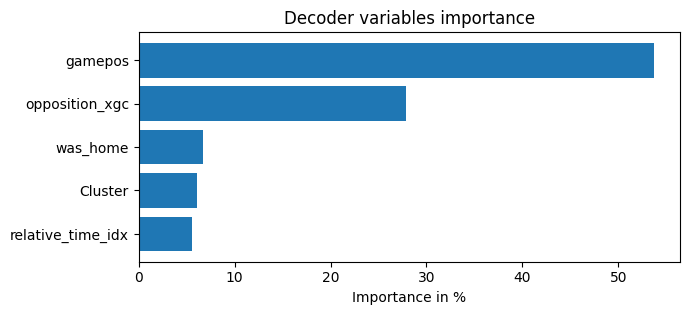

In [23]:
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch import Trainer, seed_everything
import torch
import torch.nn as nn
criterion = nn.MSELoss()

def train_data(k, batch):
    max_prediction_length = 5
    max_encoder_length = k

    training = TimeSeriesDataSet(
        X_train,
        time_idx="time",
        target="total_points",
        group_ids=["name"],  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_encoder_length=max_encoder_length,
        static_categoricals=static,
        allow_missing_timesteps=True,
        categorical_encoders={
        "gamepos": NaNLabelEncoder(add_nan=True),  # Handle unknown categories
        "name" : NaNLabelEncoder(add_nan=True)
    },

    
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        time_varying_known_categoricals=knowncat,
        time_varying_known_reals=knowncont,
        time_varying_unknown_reals=unknown,
        target_normalizer=TorchNormalizer(),
        add_relative_time_idx=True,
        #add_target_scales=True,
        #add_encoder_length=True,


    )

    validation = TimeSeriesDataSet.from_dataset(training, X_test, predict=True, stop_randomization=True)

    batch_size = batch # set this between 32 to 128
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=8,persistent_workers=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=8,persistent_workers=True)
    data_df = training.data
    return train_dataloader, val_dataloader,training

def train_model(AH,HS,HCS,train_dataloader, val_dataloader,training,s,e,lstm):
    


    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-6, patience=10, verbose=False, mode="min")
    lr_logger = LearningRateMonitor()  # log the learning rate
    logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

    #seed_everything(s, workers=True)
    q=[0.1,0,2, 0.25,0.5,0.75,0.8, 0.9]
    trainer = pl.Trainer(
        max_epochs=e,
        enable_model_summary=True,
        gradient_clip_val=0.1,
        callbacks=[lr_logger],
        logger=logger,
    )

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.01,
        hidden_size=HS,
        attention_head_size=AH,
        dropout=0.2,
        hidden_continuous_size=HCS,
        loss=RMSE(),
        log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
        optimizer="Ranger",
        lstm_layers=lstm,
        reduce_on_plateau_patience=100,
    
    
    
    )


    
    trainer.fit(
        tft,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader,
    
    )
    return tft

def validation(tft,ki):
    criterion = nn.MSELoss()
    player_list=["Son_Heung-min","Kevin_De Bruyne","Phil_Foden","Erling_Haaland","Alejandro_Garnacho","Anthony_Gordon","James_Maddison",
            "Pedro_Porro","Jarrod_Bowen","Hwang_Hee-chan","Matheus_Santos Carneiro Da Cunha","Pedro_Lomba Neto","Gabriel_dos Santos Magalhães","Kai_Havertz","Gabriel_Martinelli Silva",
            "Martin_Ødegaard","Bukayo_Saka","Benjamin_White","Leon_Bailey","Ollie_Watkins","Dominic_Solanke","Illia_Zabarnyi","Ivan_Toney","Pervis_Estupiñán",
            "Pascal_Groß","Cole_Palmer","Joachim_Andersen","Eberechi_Eze","Michael_Olise","Vitalii_Mykolenko","Luis_Díaz","Mohamed_Salah","Virgil_van Dijk","Darwin_Núñez Ribeiro",
            "Julián_Álvarez","Charlie_Taylor","Jean-Philippe_Mateta","Dominic_Calvert-Lewin","Trent_Alexander-Arnold","Alfie_Doughty",
             "Bruno_Borges Fernandes","William_Saliba","Lucas_Digne","Moussa_Diaby","Mark_Flekken","Kaoru_Mitoma","Malo_Gusto","Nicolas_Jackson",
            "Bernd_Leno","Jack_Grealish","Marcus_Rashford","Alexander_Isak","Dan_Burn","Kieran_Trippier","Morgan_Gibbs-White","Richarlison_de Andrade"
            ,"Rayan_Aït-Nouri","Pablo_Sarabia","Rodrigo_Hernandez","Joško_Gvardiol","Diogo_Dalot Teixeira","Rasmus_Højlund","Martin_Dubravka","Fabian_Schär","Anthony_Elanga",
           "David_Raya Martin","Emiliano_Martínez Romero","Bryan_Mbeumo","Sergio_Reguilón","Lewis_Dunk","Ben_Chilwell","Conor_Gallagher","Dean_Henderson","Jordan_Pickford",
           "Alexis_Mac Allister","Dejan_Kulusevski","Vladimír_Coufal","Ben_Davies","Harry_Maguire","Timothy_Castagne","Tyrick_Mitchell","Rico_Henry"]
    player_list= df2['name'].unique()
    player_preds=[]
    MSE_preds=[]
    MSE_real=[]
    for i in range (len(player_list)):
        try:
            preds_list=[]
            player=player_list[i]
            preds_list.append(player)
            filtered_df = df[df['name'].isin(preds_list)]
            filtered_df=df2[df2["name"].isin(preds_list)]
            if(len(filtered_df)==0):
                continue
        

            val_dataloader=predset(filtered_df,ki)
            raw_predictions =tft.predict(val_dataloader, mode="raw", return_x=True)

            idx=0
            if(len(raw_predictions[1]['decoder_time_idx'])>1 and raw_predictions[1]['decoder_time_idx'][0][0]<raw_predictions[1]['decoder_time_idx'][1][0] ):
                idx=1
            for t in range (len(raw_predictions[1]['decoder_target'][idx])):
                MSE_real.append(raw_predictions[1]['decoder_target'][idx][t])
            preds=raw_predictions[0][0][idx]
            for j in range(len(preds)):
                preds_list.append(preds[j][0].item())
                MSE_preds.append(preds[j][0].item())
            for k in range(len(preds)):
                preds_list.append(preds[k][-1].item())
            player_preds.append(preds_list)
        except:
            continue
    interpretation = tft.interpret_output(raw_predictions.output, reduction="mean")
    tft.plot_interpretation(interpretation)
    return criterion(torch.tensor(MSE_preds), torch.tensor(MSE_real))


Hidden_size=[32,64,128]
HCS=[16,32,64]
AH=[1,4,8]
batch=[32,64]
ki=[10,12,15]

#best(16,16,4,64,12,50,32)
Hidden_size=[32,64,64]
HCS=[4,4,8]
AH=[1,1,1]
batch=[64,64,32]
ki=[5,5,5]
seeds=[33,33,33]
epochs=[5,5,5]
lstms=[1,1,1]
unknowns=[["expected_assists","expected_goals","total_points","minutes","goals_scored"]]
knowncats=[["Cluster","was_home","gamepos"]]
knowncont=["opposition_xgc"]
static=["name","Own_cluster"]
MSE=[]
features=[]
for y in range(len(Hidden_size)):
    HS=Hidden_size[y]
    hidden_CS=HCS[y]
    attention=AH[y]
    b=batch[y]
    look=ki[y]
    e=epochs[y]
    lstm=lstms[y]
    s=seeds[y]
    for t in range (len(unknowns)):
        unknown=unknowns[t]
        knowncat=knowncats[t]
        concatenated_string = str(HS) + str(hidden_CS) + str(attention)+ str(b) + str(look)+str(s)+str(e)+str(lstm)
        features.append(concatenated_string)
        train_dataloader, val_dataloader,training=train_data(look, b)
        tft=train_model(attention,HS,hidden_CS,train_dataloader, val_dataloader,training, s,e,lstm)
        
        error=validation(tft,look)
        MSE.append(error)
        print(features)
        print(MSE)
        
        

min_index = MSE.index(min(MSE))
print("fasit")
print(features[min_index])
                    
                    

#['20816453251', '20816453351', '208164532101']
#[tensor(8.4067), tensor(8.1806), tensor(9.0813)]

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:4: SyntaxWarning: invalid escape sequence '\O'
  package_path="C:\\Users\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\pytorch-forecasting"


88
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge Luiz_Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice' 'Bukayo_Saka'
 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney' 'Leandro_Trossard'
 'Benjamin_White' 'Oleksandr_Zinchenko' 'Norberto_Murara Neto'
 'Raheem_Sterling' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego Carlos_Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Robin_Olsen' 'Pau_Torres' 'Jacob_Ramsey' 'Morgan_Rogers'
 'Youri_Tielemans' 'Ollie_Watkins' 'Amadou_Onana' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed_Traorè' 'Milos_Kerkez' 'Justin_Kluivert'
 'Chris_Mepham' 'Dango_Ouattara' 'Philip_Billing' 'Alex_Scott'
 'A

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:373: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:374: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:390: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



DEF


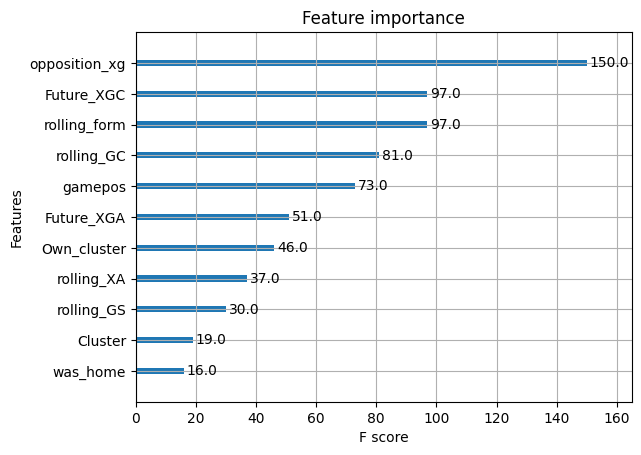

tensor(2.7721)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

DEF
Gabriel_dos Santos Magalhães


TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


['Gabriel_dos Santos Magalhães', 3.9406774044036865, 3.3708980083465576, 3.222362995147705, 4.553417205810547, 3.5356054306030273, 1.0, 2.0, 3.0, 4.0, 5.0]
Jurriën_Timber


...

['Aymeric_Laporte', 3.1392993927001953, 2.5931525230407715, 3.070091962814331, 2.904273271560669, 2.395801067352295, 1.0, 2.0, 3.0, 4.0, 5.0]
Joel_Matip


HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


['Joel_Matip', 1.260115385055542, 2.549518585205078, 2.488954544067383, 2.349261999130249, 1.7309391498565674, 1.0, 2.0, 3.0, 4.0, 5.0]
Junior_Firpo Adames


C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\lightning\pytorch\trainer\call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_22916\3668823940.py:4: SyntaxWarning: invalid escape sequence '\O'
  package_path="C:\\Users\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\pytorch-forecasting"


IndexError: list index out of range

In [2]:
import sys
import os

package_path="C:\\Users\OleJacobSimensen\\OneDrive - twoday\\Documents\\Python_test\\pytorch-forecasting"

# Check if the directory exists
if os.path.exists(package_path):
    # Add the package path to sys.path
    sys.path.append(package_path)
import numpy as np
import xgboost as xgb
import pandas as pd
from pytorch_forecasting.data.encoders import NaNLabelEncoder
import lightning.pytorch as pl
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer,TorchNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss,MultiHorizonMetric,RMSE
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch import Trainer, seed_everything
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn as nn
criterion = nn.MSELoss()
df=pd.read_csv("testML.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        unique_pos=new_filtered['position'].unique()
        for u in range(len(unique_pos)):
            times=[]
            pos=unique_pos[u]
            pos_filter=new_filtered[new_filtered['position'] == pos]
            filtered = pos_filter[pos_filter["minutes"] > 0]
            for g in range(len(filtered)):
                times.append(max_t-g)
            times.reverse()
            filtered["time"]=times
            if(len(unique_teamvals)>1):
                filtered['name']=filtered['name'].values[0]+str(t)
            time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
time_df.to_csv("ML_training2.csv")


def Make_TFT_Train(position,pred, pred_length, position_dict):
    offset=0
    if pred:
        lb1=10+offset
        lb2=5+offset
        lb3=0+offset
    else:
        print('training')
        lb1=15
        lb2=10
        lb3=5
        
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc
    df["Team"]=df["Team"].astype(str)
    df["element"]=df["element"].astype(str)
    df["Cluster"]=df["Cluster"].astype(str)
    df["was_home"]=df["was_home"].astype(str)
    df["gamepos"]=df["gamepos"].astype(str)
    df["season"]=df["season"].astype(str)
    df.replace([np.inf, -np.inf], 1, inplace=True)
    df["Own_cluster"]=df["Own_cluster"].astype(str)
    df['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
    df['Future_XG'] = df['Rolling_adjusted_XG2']*df['opposition_xgc']*df['Capped_Average_Overscore']
    df['Future_XGC'] = df['Rolling_adjusted_XGC2']*df['opposition_xg']
    df['Future_XGA'] = df['Rolling_adjusted_XA2']*df['opposition_xgc']
    
    unknown=["assists", "bps","clean_sheets", "expected_assists","expected_goals","expected_goals_conceded","total_points","minutes","goals_scored","rolling_form" ]
    knowncat=["Cluster","was_home","gamepos","season"]
    knowncont=["opposition_xg","opposition_xgc",]
    static=["name","Own_cluster"]
    if(position=="GK"):
        unknown=["clean_sheets","expected_goals_conceded","total_points","rolling_form","goals_conceded","Rolling_adjusted_XGC2"]
        knowncat=["Cluster","was_home"]
        knowncont=["opposition_xg","Future_XGC"]
        static=["name","Own_cluster"]
        static_reals=[]

    if(position=="DEF"):
        unknown=["expected_goals_conceded","total_points","rolling_XA","rolling_XG","clean_sheets","Rolling_adjusted_XGC"]
        knowncat=["Cluster","was_home","gamepos"]
        knowncont=["opposition_xg","Future_XGC"]
        static=["Own_cluster"]
        static_reals=[]

    if(position=="FWD"):
        unknown=["rolling_XA","goals_scored","rolling_XG","total_points","assists","Rolling_adjusted_XG2"]
        knowncat=["Cluster","was_home","gamepos"]
        knowncont=["opposition_xgc","Future_XG","Future_XGA"]
        static=["Own_cluster"]
        static_reals=[]

    if(position=="MID" ):
        unknown=["rolling_XA","total_points","goals_scored","assists","rolling_XG"]
        knowncat=["Cluster","was_home","gamepos"]
        knowncont=["opposition_xgc","Future_XG","Future_XGA"]
        static=["Own_cluster"]
        static_reals=[]
    df['Overscore'] = df['Overscore'].fillna(0.8)
    df['Average_Overscore'] = df['Average_Overscore'].fillna(0.8)
    df['Rolling_adjusted_XGC2'] = df['Rolling_adjusted_XGC2'].fillna(1)
    df['Rolling_adjusted_XGC'] = df['Rolling_adjusted_XGC'].fillna(1.3)
    df['Rolling_adjusted_XG2'] = df['Rolling_adjusted_XG2'].fillna(0.3)
    df['Future_XG'] = df['Future_XG'].fillna(0)
    df['Future_XGC'] = df['Future_XGC'].fillna(0)
    df['Future_XGA'] = df['Future_XGA'].fillna(0)
    X_train=pd.DataFrame()
    names= df['name'].unique()
    df=df[df['position'] == position]
    for i in range(len(names)):
        name=names[i]
        filtered= df[df['name'] == name]
        training_cutoff = filtered["time"].max() - lb1

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    scalers = {}
    for feature in unknown:
        if feature != 'total_points':
            scaler = StandardScaler()
            X_train[feature] = scaler.fit_transform(X_train[[feature]])
            scalers[feature] = scaler
    
    for feature in knowncont:
        scaler = StandardScaler()
        X_train[feature] = scaler.fit_transform(X_train[[feature]])
        scalers[feature] = scaler 
        
    full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    extra=X_train[X_train['name'].isin(full)]
    extra['name']=extra['name']+'r'
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)
    
    X_test=pd.DataFrame()
    for i in range(len(names)):
        name=names[i]
        filtered= df[df['name'] == name]
        training_cutoff = filtered["time"].max() - lb2
        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)
        
    for feature, scaler in scalers.items():
        X_test[feature] = scaler.transform(X_test[[feature]])
        
    df2=pd.DataFrame()
    for i in range(len(names)):
        name=names[i]
        filtered= df[df['name'] == name]
        training_cutoff = filtered["time"].max() - lb3
        name_df=filtered[lambda x: x.time <= training_cutoff]
        df2=pd.concat([df2, name_df], axis=0, ignore_index=True)
    for feature, scaler in scalers.items():
        df2[feature] = scaler.transform(df2[[feature]])
    max_prediction_length = pred_length
    max_encoder_length = position_dict["lookb"]

    training = TimeSeriesDataSet(
        X_train,
        time_idx="time",
        target="total_points",
        group_ids=["name"],  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_encoder_length=max_encoder_length,
        static_categoricals=static,
        static_reals=static_reals,
        allow_missing_timesteps=True,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        time_varying_known_categoricals=knowncat,
        time_varying_known_reals=knowncont,
        time_varying_unknown_reals=unknown,
        target_normalizer=TorchNormalizer(),
        categorical_encoders={
            "gamepos": NaNLabelEncoder(add_nan=True),  # Handle unknown categories
            "name" : NaNLabelEncoder(add_nan=True)
        },
        add_relative_time_idx=True,
        #add_target_scales=True,
        #add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(training, X_test, predict=True, stop_randomization=True)

    batch_size = 64 # set this between 32 to 128
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=10,persistent_workers=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=8, num_workers=10,persistent_workers=True)
    return train_dataloader, val_dataloader,df2,training,static,knowncat,knowncont,unknown,static_reals

def Train_TFT(Train_dataloader, val_dateloader, training, paramlist,position):

    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-6, patience=2, verbose=False, mode="min")
    lr_logger = LearningRateMonitor()  # log the learning rate
    logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard
    #seed_everything(paramlist["Seed"], workers=True)
    
    q=[0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    trainer = pl.Trainer(
        max_epochs=15,
        enable_model_summary=True,
        gradient_clip_val=0.1,
        callbacks=[early_stop_callback, lr_logger]  # Add callbacks here
    )

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=paramlist["LR"],
        hidden_size=paramlist["HS"],
        attention_head_size=paramlist["AH"],
        dropout=paramlist["DO"],
        hidden_continuous_size=paramlist["HCS"],
        loss=RMSE(),
        #log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
        optimizer="Ranger",
        lstm_layers=1,
        reduce_on_plateau_patience=10,
    )
    print(position)
    """trainer.fit(
        tft,
        train_dataloaders=Train_dataloader,
        val_dataloaders=val_dateloader)
    
    #if(position=="FWD"):
        #torch.save(tft.state_dict(), 'TFT_FWD1.pth')
    #if(position=="DEF"):
        #torch.save(tft.state_dict(), 'TFT_DEF2.pth')
    #if(position=="MID"):
        #torch.save(tft.state_dict(), 'TFT_MID2.pth')"""
   
    if(position=="MID"):
        checkpoint = torch.load('TFT_MID2.pth')
        tft.load_state_dict(checkpoint)
        tft.eval()       
    elif(position=="FWD"):
        checkpoint = torch.load('TFT_FWD1.pth')
        tft.load_state_dict(checkpoint)
        tft.eval()
    elif(position=="DEF"):
        checkpoint = torch.load('TFT_DEF2.pth')
        tft.load_state_dict(checkpoint)
        tft.eval()
    else:
        trainer.fit(
            tft,
            train_dataloaders=Train_dataloader,
            val_dataloaders=val_dateloader)
        
    
    return tft
def TFT_predset(filtered_df,ki,static,knowncat,knowncont,unknown,static_reals):
    max_prediction_length = 5
    max_encoder_length = ki
    training = TimeSeriesDataSet(
        filtered_df,
        time_idx="time",
        target="total_points",
        group_ids=["name"],  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_encoder_length=5,
        static_categoricals=static,
        static_reals=static_reals,
        allow_missing_timesteps=True,
        time_varying_known_reals=knowncont,
        min_prediction_length=max_prediction_length,
        max_prediction_length=max_prediction_length,
        time_varying_known_categoricals=knowncat,
        time_varying_unknown_reals=unknown,
        categorical_encoders={
            "gamepos": NaNLabelEncoder(add_nan=True),  # Handle unknown categories
            "name" : NaNLabelEncoder(add_nan=True)
        },
        target_normalizer=TorchNormalizer(),
        #add_relative_time_idx=True,
        predict_mode=True,
        #add_target_scales=True,
        add_relative_time_idx=True,
    )

    validation = TimeSeriesDataSet.from_dataset(training, filtered_df, predict=True, stop_randomization=True)
    batch_size = 1 # set this between 32 to 128
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=8,persistent_workers=True)
    return val_dataloader
    
    
    
def TFT_Generate_predictions(df2,static,knowncat,knowncont,unknown, params, tft,static_reals):
    player_list= df2['name'].unique()

    player_preds=[]
    MSE_preds=[]
    MSE_real=[]
    for i in range (len(player_list)):
        preds_list=[]
        player=player_list[i]
        print(player)
        preds_list.append(player)
        filtered_df = df[df['name'].isin(preds_list)]
        filtered_df=df2[df2["name"].isin(preds_list)]
        if(len(filtered_df)<10):
            continue
        lookb=params["lookb"]
        val_dataloader=TFT_predset(filtered_df,lookb,static,knowncat,knowncont,unknown,static_reals)
        raw_predictions =tft.predict(val_dataloader, mode="raw", return_x=True)
        idx=0
        if(len(raw_predictions[1]['decoder_time_idx'])>1 and raw_predictions[1]['decoder_time_idx'][0][0]<raw_predictions[1]['decoder_time_idx'][1][0] ):
            idx=1
        for t in range (len(raw_predictions[1]['decoder_target'][idx])):
            MSE_real.append(raw_predictions[1]['decoder_target'][idx][t])
        preds=raw_predictions[0][0][idx]
        for j in range(len(preds)):
            preds_list.append(preds[j][0].item())
            MSE_preds.append(preds[j][0].item())
        for k in range(len(preds)):
            preds_list.append(raw_predictions[1]['decoder_target'][idx][k].item())
        player_preds.append(preds_list)
        print(preds_list)
    print(criterion(torch.tensor(MSE_preds), torch.tensor(MSE_real)))
    columns=["Name","p1","p2","p3","p4","p5","top1","top2","top3","top4","top5"]
    data_f=pd.DataFrame(player_preds, columns=columns)
    return data_f,raw_predictions

    
def Make_TFT_Predictions(position,pred_length, position_index,pred):
    position_params={}
    paramslist=[[5,5,5,5], [1,1,1,1],[20,20,20,20], [4,4,4,4], [0.01, 0.01,0.01,0.01], [0.1,0.2,0.2,0.1],[33,33,32,33]]
    position_params["lookb"]=paramslist[0][position_index]
    position_params["AH"]=paramslist[1][position_index]
    position_params["HS"]=paramslist[2][position_index]
    position_params["HCS"]=paramslist[3][position_index]
    position_params["LR"]=paramslist[4][position_index]
    position_params["DO"]=paramslist[5][position_index]
    position_params["Seed"]=paramslist[6][position_index]
    cutoff=15
    Pred_df=pd.DataFrame
    for i in range(1):
        train_dataloader, val_dataloader,df2, training,static,knowncat,knowncont,unknown,static_reals=Make_TFT_Train(position,pred, pred_length, position_params)
        tft=Train_TFT(train_dataloader, val_dataloader, training, position_params,position)
        preds,raw_predictions=TFT_Generate_predictions(df2,static,knowncat,knowncont,unknown,position_params,tft,static_reals)
        cutoff-=1
    interpretation = tft.interpret_output(raw_predictions.output, reduction="mean")
    tft.plot_interpretation(interpretation)
    return preds


def XGB_Make_dataset(position):
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    df=df[df['position'] == position]


    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)

    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc

    trainingdf=df[["opposition_xg","Average_Overscore","opposition_xgc", "rolling_form","rolling_XG","Team","name","position","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos","rolling_ICT","Overscore","XGC_DEF","XGC_FWD","XGC_MID"
                   ,"Rolling_adjusted_XG2","Rolling_adjusted_XGC2","Rolling_adjusted_XA2"]]
    
    
    names= df['name'].unique()
    time_df=pd.DataFrame()
    for i in range(len(names)):
        times=[]
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        filtered['rolling_form'] = filtered['rolling_form'].shift(1)
        filtered['rolling_XG'] = filtered['rolling_XG'].shift(1)
        filtered['rolling_GS'] = filtered['rolling_GS'].shift(1)
        filtered['rolling_GC'] = filtered['rolling_GC'].shift(1)
        filtered['rolling_XA'] = filtered['rolling_XA'].shift(1)
        filtered['rolling_ICT'] = filtered['rolling_ICT'].shift(1)
        #filtered['Rolling_adjusted_XGC'] = filtered['Rolling_adjusted_XGC'].shift(1)
        #filtered['Rolling_adjusted_XG'] = filtered['Rolling_adjusted_XG'].shift(1)
        filtered['Overscore'] = filtered['Overscore'].shift(1)
        filtered['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
        filtered['Future_XG'] = filtered['Rolling_adjusted_XG2']*filtered['opposition_xgc']*filtered['Capped_Average_Overscore']
        filtered['Future_XGC'] = filtered['Rolling_adjusted_XGC2']*filtered['opposition_xg']
        filtered['Future_XGA'] = filtered['Rolling_adjusted_XA2']*filtered['opposition_xgc']

        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
    
    trainingdf=time_df

    trainingdf['Team'] = trainingdf['Team'].astype('category')
    trainingdf['name'] = trainingdf['name'].astype('category')
    trainingdf['position'] = trainingdf['position'].astype('category')
    trainingdf['gamepos'] = trainingdf['gamepos'].astype('category')
    trainingdf.replace([np.inf, -np.inf], 1, inplace=True)
    if(position=='FWD'):
        trainingdf=trainingdf[["opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos","Future_XG","Future_XGA"]]
    elif(position=='DEF'):
        trainingdf=trainingdf[["opposition_xg","rolling_form","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos",'Future_XGC',"Future_XGA"]]
    elif(position=='GK'):
        trainingdf=trainingdf[["opposition_xg","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GC","time","gamepos"]]
    else:
        trainingdf=trainingdf[["opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos",'Future_XG',"Future_XGA"]]
    trainingdf.to_csv("xgb_test_data.csv")
    print(position)
    return trainingdf

def XGB_Train(rounds, eta,max_depth,gamma,min_c,dtrain ):
    params = {
        'max_depth': max_depth,
        'eta': eta,
        'objective': 'reg:squarederror',  # Use 'reg:squarederror' for regression
        'eval_metric': 'rmse',             # Use 'rmse' (root mean squared error) for evaluation
        'tree_method':'hist',
        'grow_policy': 'lossguide',
        'gamma':gamma,
        'min_child_weight': min_c
    }

    num_rounds = rounds
    xgb_model = xgb.train(params, dtrain, num_rounds)
    return xgb_model

def XGB_Make_Pred(trainingdf):
    X_train=pd.DataFrame()
    names= trainingdf['name'].unique()


    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - 10

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    """full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)"""
    
    X_test=pd.DataFrame()
    
    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - 5
        training_cutoff2 = filtered["time"].max() - 0
        name_df=filtered[lambda x: x.time > training_cutoff]
        name_df=name_df[lambda x: x.time <= training_cutoff2]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

    total=[]
    
    Y_train=X_train[["total_points"]]
    Y_test=X_test[["total_points"]]

    train = X_train.drop(columns=['total_points','time',"name","Team"])
    test = X_test.drop(columns=['time'])

    dtrain = xgb.DMatrix(train, label=Y_train,enable_categorical=True)

    dtest = xgb.DMatrix(test, label=Y_test,enable_categorical=True)



    preds_list=test['name'].unique()

    model=XGB_Train(50,0.1,4,0.01,8,dtrain )
    row2=[]
    actuals=[]
    for i in range(len(preds_list)):
        row=[]
        player=[]
        player.append(preds_list[i])
        row.append(preds_list[i])
        filtered_df = test[test['name'].isin(player)]
        y=filtered_df[["total_points"]]
        filtered_df = filtered_df.drop(columns=['total_points','name',"Team"])
        dtest = xgb.DMatrix(filtered_df, label=y,enable_categorical=True)
        y_pred = model.predict(dtest)
        for g in range(len(y_pred)):
            row.append(y_pred[g])
            row2.append(y_pred[g])
        for t in range(len(y_pred)):
            row.append(y.values[t][0])
            actuals.append(y.values[t][0])

        total.append(row)
    from xgboost import plot_importance
    import matplotlib.pyplot as plt

    # Plot feature importance
    plot_importance(model, importance_type='weight')
    plt.show()
        
    print(criterion(torch.tensor(row2), torch.tensor(actuals)))
    columns=["Name","p1","p2","p3","p4","p5","y1","y2","y3","y4","y5"]
    data_f=pd.DataFrame(total, columns=columns)
    return data_f
def XGB(position):
    data=XGB_Make_dataset(position)
    pred=XGB_Make_Pred(data)
    return pred
def Make_Predictions ():
    predlength=5
    is_pred=1
    positions=["FWD", "DEF","GK","MID"]
    positions=["DEF"]
    TFT_pred=pd.DataFrame()
    XGB_pred=pd.DataFrame()
    for i in range(len(positions)):
        position_filter=positions[i]
        pred2=XGB(position_filter)
        XGB_pred=pd.concat([XGB_pred, pred2], axis=0, ignore_index=True)
        pred1=Make_TFT_Predictions(position_filter,predlength, i,is_pred)
        TFT_pred=pd.concat([TFT_pred, pred1], axis=0, ignore_index=True)
        
        
    TFT_pred.to_csv("TFT_preds.csv")
    XGB_pred.to_csv("XGB_preds.csv")

         
        
if __name__ == '__main__':
    Make_Predictions()


#XGB
#ATTK-7.33
#DEF-5.62
#KEP-7.57
#MID-5.8

#TFT
#ATTK-7.81
#DEF-5.9
#GK-6.97
#MID-6.4

#Att_list=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva','Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha',
#'Dominic_Solanke']
#DEF_list=['Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson'
#'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri']
#MID=['Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke'
#'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0'
#'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen'




In [46]:
TFT_pred=pd.read_csv("TFT_preds.csv")
df_grouped = TFT_pred.groupby('Name', as_index=False).mean()
df_grouped.to_csv("TFT_preds.csv")

XGB_pred=pd.read_csv("XGB_preds.csv")
df_grouped = XGB_pred.groupby('Name', as_index=False).mean()
df_grouped.to_csv("XGB_preds.csv")

In [47]:
import requests
import pandas as pd
import numpy as np
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
r = requests.get(url)
json = r.json()


elements_df = pd.DataFrame(json['elements'])
elements_types_df = pd.DataFrame(json['element_types'])
teams_df = pd.DataFrame(json['teams'])

print(elements_df.columns)

slim_elements_df = elements_df[['id','cost_change_event','chance_of_playing_next_round','first_name','second_name','team','element_type','selected_by_percent',
                                'now_cost','minutes','value_season','web_name','total_points','goals_conceded_per_90','team_code','goals_scored',
       'assists', 'clean_sheets', 'goals_conceded','saves', 'bonus', 'bps','expected_goals', 'expected_assists','corners_and_indirect_freekicks_order','penalties_order','expected_goals_per_90', 'saves_per_90', 'expected_assists_per_90','expected_goals_conceded']]
slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)


id=slim_elements_df['first_name'].values
name=slim_elements_df['second_name'].values
id_string=id+"_"+name

link_df=pd.DataFrame()
link_df["Name"]=id_string
link_df["Team"]=slim_elements_df['team'].values
link_df["Cost"]=slim_elements_df['now_cost'].values
link_df["Position_ID"]=slim_elements_df['element_type'].values
link_df["Ownership"]=slim_elements_df['selected_by_percent'].values

link_df.to_csv("players_list.csv")

Index(['chance_of_playing_next_round', 'chance_of_playing_this_round', 'code',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'dreamteam_count', 'element_type', 'ep_next',
       'ep_this', 'event_points', 'first_name', 'form', 'id', 'in_dreamteam',
       'news', 'news_added', 'now_cost', 'photo', 'points_per_game',
       'second_name', 'selected_by_percent', 'special', 'squad_number',
       'status', 'team', 'team_code', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'region', 'minutes',
       'goals_scored', 'assists', 'clean_sheets', 'goals_conceded',
       'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards',
       'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity',
       'threat', 'ict_index', 'starts', 'expected_goals', 'expected_assists',
       'expected_goal_involvements', 'expected

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_27268\2954851845.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_27268\2954851845.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_44804\2582014021.py:11: SyntaxWarning: invalid escape sequence '\d'
  tft_train['time'] = tft_train['time'].str.extract('(\d)').astype(int)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_44804\2582014021.py:21: SyntaxWarning: invalid escape sequence '\d'
  xg_train['time'] = xg_train['time'].str.extract('(\d)').astype(int)


                         Name        p1        p2        p3        p4  \
0   Gabriel_Fernando de Jesus  3.522003  3.690113  3.106000  2.853515   
1                Kai_Havertz0  7.672828  5.980467  7.199113  1.455696   
2                Kai_Havertz1  7.672828  5.980467  7.199113  1.455696   
3                  Jhon_Durán  2.666507  2.074508  2.512094  3.941041   
4               Ollie_Watkins  3.190890  4.069294  3.265634  7.835373   
..                        ...       ...       ...       ...       ...   
95             Cauley_Woodrow  1.577052  1.666477  1.426794  1.617352   
96               Bénie_Traoré  1.596132  1.026463  1.250688  1.148418   
97                Lyle_Foster  2.975821  3.555445  4.028913  4.549779   
98                Jacob_Brown  2.596935  2.508096  2.439236  2.000204   
99               Divock_Origi  3.245545  0.756134  0.740520  1.317017   

          p5  y1  y2  y3  y4  y5  
0   3.175347   1   0   1   0   1  
1   6.822048   2   8   2   2   6  
2   6.822048   2  

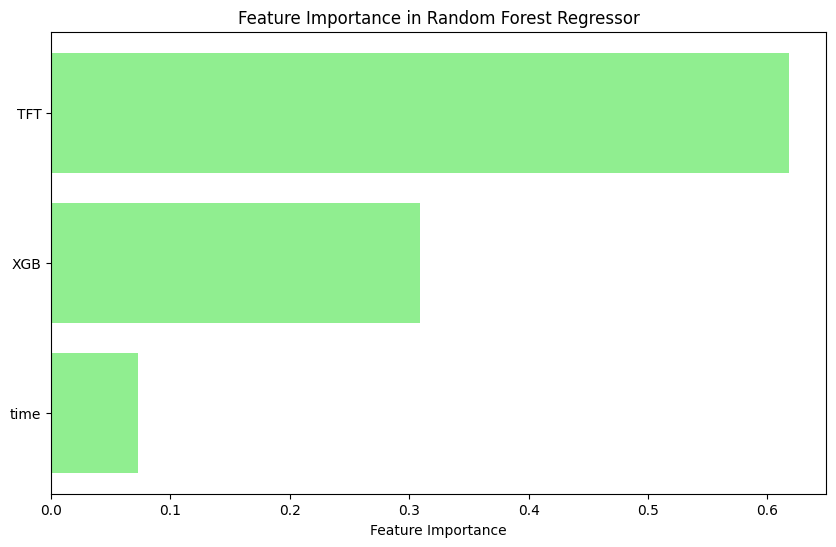

time: -0.0048
TFT: 0.7116
XGB: 0.3651
Intercept: -0.3229
   time       TFT       XGB
0     1  3.273507  3.522003
1     1  5.889309  7.672828
2     1  6.682970  7.672828
3     1  1.350218  2.666507
4     1  4.571594  3.190890
0    1.0
1    2.0
2    2.0
3    1.0
4    2.0
Name: y, dtype: float64
[1.04 2.62 2.85 1.26 2.55]
[3.28759359 6.66441718 7.22917537 1.606667   4.09040696]


In [62]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
xg_pd=pd.read_csv("XGB_preds1.csv")[["Name", "p1","p2","p3","p4","p5", "y1","y2","y3","y4","y5"]]
tft_pd=pd.read_csv("TFT_preds1.csv")[["Name", "p1","p2","p3","p4","p5", "top1","top2","top3","top4","top5"]]
print(xg_pd)

tft_train = pd.melt(tft_pd, id_vars=['Name'], value_vars=["p1","p2","p3","p4","p5"], 
                    var_name='time', value_name='TFT')
tft_train['time'] = tft_train['time'].str.extract('(\d)').astype(int)
tft_test = pd.melt(tft_pd, id_vars=['Name'], value_vars=["top1","top2","top3","top4","top5"], 
                    var_name='time', value_name='TFT')
tft_train["Model"]=[1]*len(tft_train)
tft_train["y"]=tft_test["TFT"].values



xg_train = pd.melt(xg_pd, id_vars=['Name'], value_vars=["p1","p2","p3","p4","p5"], 
                    var_name='time', value_name='XGB')
xg_train['time'] = xg_train['time'].str.extract('(\d)').astype(int)
xg_test = pd.melt(xg_pd, id_vars=['Name'], value_vars=["y1","y2","y3","y4","y5"], 
                    var_name='time', value_name='XGB')
xg_train["Model"]=[0]*len(xg_train)
xg_train["y"]=xg_test["XGB"].values

print(tft_train)
common_names=tft_train["Name"].values
xg_train = xg_train[xg_train['Name'].isin(common_names)]
print(len(common_names))
print(len(xg_train["Name"].values))
ENSAMBLE=tft_train
ENSAMBLE["XGB"]=xg_train["XGB"].values
ENSAMBLE.to_csv("ENSAMBLE_training.csv")
print(ENSAMBLE)


ENSAMBLE
X_train=ENSAMBLE[["time","TFT","XGB"]]
y_train=ENSAMBLE["y"]
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

feature_importances = rf_regressor.feature_importances_
feature_names = X_train.columns

# 6. Create a DataFrame for better readability
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 7. Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightgreen')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Regressor')
plt.gca().invert_yaxis()  # To display the highest importance at the top
plt.show()

coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {intercept:.4f}')

X_test=X_train.head()
print(X_test)
print(y_train.head())
y_pred = rf_regressor.predict(X_test)
y_pred2 = linear_regressor.predict(X_test)
print(y_pred)
print(y_pred2)

In [21]:
import joblib
joblib.dump(linear_regressor, 'linear_regression_model.joblib')

['linear_regression_model.joblib']